In [ ]:
import seaborn as sns
import pandas as pd

# Importiamo il dataset di titanic
df = sns.load_dataset('titanic')

# Mostra le prime 5 righe
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

In [ ]:
# Stampiamo tutte le info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
# Contiamo le righe nulle di ogni colonna
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
# Cancelliamo le colonne ridondanti o con troppi valori nulli
df = df.drop(columns=['deck', 'alive', 'class', 'embark_town','alone', 'adult_male','who'])

In [ ]:
# Riempiamo i valori nulli con moda/mediana
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Ricontrolliamo il numero di valori nulli per vedere se tutto ha funzionato
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [ ]:
# Controlliamo se ci sono duplicati
df.duplicated().sum()

np.int64(116)

In [ ]:
# Cancelliamo i duplicati e ricontrolliamo se ha funzionato
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
# Controlliamo i tipi di ogni colonna
df.dtypes

survived      int64
pclass        int64
sex             str
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str
dtype: object

In [ ]:
# Facciamo stampare tutti i possibili valori delle colonne "embarked", "pclass", "survived"
print(df['embarked'].unique())
print(df['pclass'].unique())
print(df['survived'].unique())

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str
[3 1 2]
[0 1]


In [ ]:
# Trasformiamo la colonna "sex" in una colonna numerica dove 0 indica un maschio e 1 una femmina
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Stampiamo tutti i possibili valori di sex per vedere se tutto ha funzionato
print(df['sex'].unique())

# Ristampiamo i tipi per vedere se resta qualcosa di non numerico
df.dtypes

[0 1]


survived      int64
pclass        int64
sex           int64
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str
dtype: object

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Inizializziamo l'encoder
ohe = OneHotEncoder(sparse_output=False)

# Trasformiamo la colonna "embarked" in 3 nuove colonne che indicheranno qual è il porto di imbarco
ohe_transformed = ohe.fit_transform(df[['embarked']])

# Creiamo un nuovo DataFrame con i nomi delle nuove colonne
df_ohe = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(['embarked']))
# Stampiamo il nuovo DataFrame
print(df_ohe)

# Resettiamo gli indici del vecchio DataFrame per renderlo compatibile con il nuovo
df = df.reset_index(drop=True)

# Concateniamo i due DataFrame e cancelliamo la colonna "embarked" che a questo punto si deduce dalle nuove colonne numeriche introdotte
df = pd.concat([df, df_ohe], axis=1)
df = df.drop(columns=['embarked'])


     embarked_C  embarked_Q  embarked_S
0           0.0         0.0         1.0
1           1.0         0.0         0.0
2           0.0         0.0         1.0
3           0.0         0.0         1.0
4           0.0         0.0         1.0
..          ...         ...         ...
770         0.0         1.0         0.0
771         0.0         0.0         1.0
772         0.0         0.0         1.0
773         1.0         0.0         0.0
774         0.0         1.0         0.0

[775 rows x 3 columns]


In [ ]:
# Ristampiamo il DataFrame per controllarne la forma attuale
print(df)

     survived  pclass  sex   age  sibsp  parch     fare  embarked_C  \
0           0       3    0  22.0      1      0   7.2500         0.0   
1           1       1    1  38.0      1      0  71.2833         1.0   
2           1       3    1  26.0      0      0   7.9250         0.0   
3           1       1    1  35.0      1      0  53.1000         0.0   
4           0       3    0  35.0      0      0   8.0500         0.0   
..        ...     ...  ...   ...    ...    ...      ...         ...   
770         0       3    1  39.0      0      5  29.1250         0.0   
771         1       1    1  19.0      0      0  30.0000         0.0   
772         0       3    1  28.0      1      2  23.4500         0.0   
773         1       1    0  26.0      0      0  30.0000         1.0   
774         0       3    0  32.0      0      0   7.7500         0.0   

     embarked_Q  embarked_S  
0           0.0         1.0  
1           0.0         0.0  
2           0.0         1.0  
3           0.0         1.0

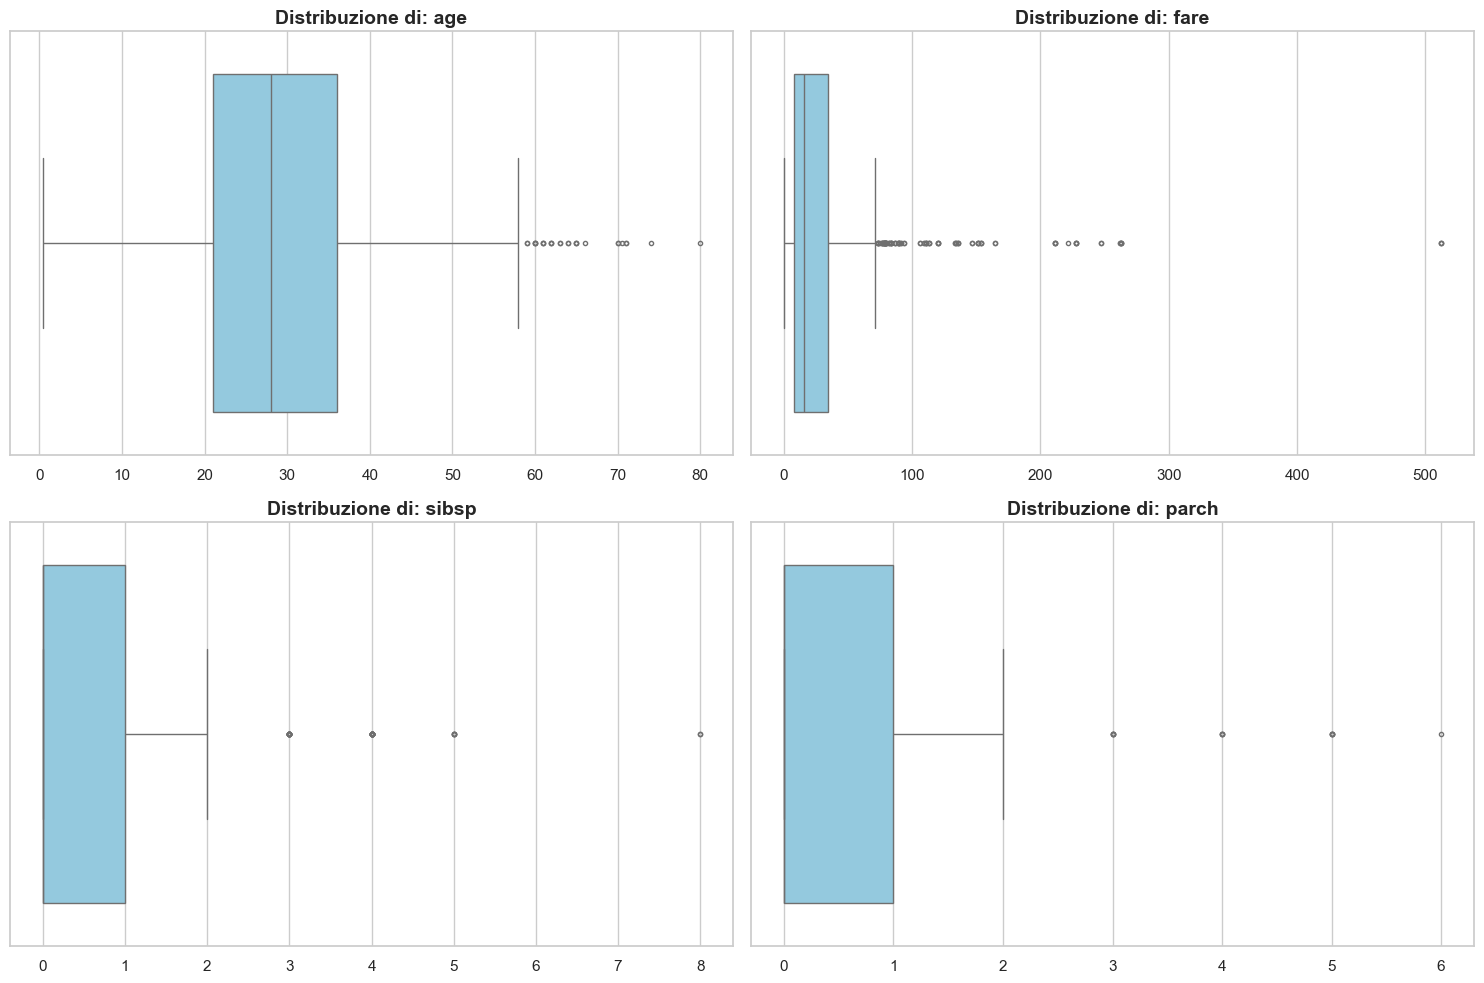

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scegliamo le colonne di cui fare il boxplot per visualizzare gli outliers
cols = ['age', 'fare', 'sibsp', 'parch']

# Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

# Ciclo per creare un boxplot per ogni colonna di quelle scelte
for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# Ottimizzazione del layout
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from scipy import stats

# Rimozione degli outliers con z-score 3
def remove_outliers_zscore(df, cols, threshold=3):
    df_clean = df.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[cols]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['age', 'fare', 'sibsp', 'parch'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Righe rimosse con Z-Score: 63
